# 00 — Data Quality Audit
REES46 "eCommerce Events History in Cosmetics Shop" — Oct 2019 through Feb 2020.

This notebook is an audit, not a model. Its job is to establish ground truth about the raw
data before any downstream notebook makes an analytical decision: what the order-reconstruction
rule should be, what retention horizon is actually measurable, what the churn-threshold candidate
range looks like, and what limitations (cookie-scoped identity, missing category data, session-ID
reuse) have to be carried forward and disclosed, not silently absorbed.

No rows are deleted here. Every irregularity found is quantified and written to
`outputs/tables/data_quality_audit.csv`. Downstream notebooks apply the documented rules
explicitly, reading certified parameters from `outputs/handoff_params.json`.

In [1]:
import os, sys, json, time
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Notebook is opened from notebooks/; anchor cwd at the project root so every
# relative path (data/raw, outputs/, src/) resolves the same way regardless of
# how Jupyter was launched.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from src.plotting import frame, add_title, add_takeaway, save, show_df, thousands

# RC-2 (2026-09-21): every reported avg() in this notebook is rounded to 6 dp IN SQL.
# DuckDB's parallel sum reduces in physical scan order, so a raw avg() written straight
# to CSV differs in its last 1-2 bits between runs -- four cells of 00's tables moved
# between two otherwise identical clean runs. 00 predates src.data.round_sig(), so the
# rounding is done at the aggregate instead. 6 dp is far finer than anything 00 reports.
SEED = 42
np.random.seed(SEED)

RAW_DIR = os.path.join("data", "raw")
RAW_GLOB = os.path.join(RAW_DIR, "*.csv")
TABLES_DIR = os.path.join("outputs", "tables")
os.makedirs(TABLES_DIR, exist_ok=True)

audit_rows = []  # accumulates every documented cleaning/quality rule for data_quality_audit.csv

def log_rule(rule, rows_affected, total_rows, reason, implication):
    pct = 100.0 * rows_affected / total_rows if total_rows else 0.0
    audit_rows.append({
        "rule": rule,
        "rows_affected": int(rows_affected),
        "pct_of_total": round(pct, 4),
        "reason": reason,
        "implication": implication,
    })
    print(f"[{rule}] {rows_affected:,} rows ({pct:.3f}%) -- {reason}")

con = duckdb.connect()
con.execute("SET memory_limit='4GB'")
con.execute("SET threads=6")
con.execute("SET enable_progress_bar=false")
con.execute(f"CREATE OR REPLACE VIEW ev AS SELECT * FROM read_csv_auto('{RAW_GLOB}', filename=true)")
print("DuckDB ready. Reading directly off CSVs on disk -- nothing is loaded into pandas in bulk.")

DuckDB ready. Reading directly off CSVs on disk -- nothing is loaded into pandas in bulk.


## 1. File / schema audit
Confirm which raw files actually exist in `data/raw/`, and that every file shares one schema
before any cross-file UNION is trusted.

In [2]:
raw_files = sorted(f for f in os.listdir(RAW_DIR) if f.endswith(".csv"))
print(f"{len(raw_files)} CSV files found in data/raw/:")
for f in raw_files:
    size_mb = os.path.getsize(os.path.join(RAW_DIR, f)) / 1e6
    print(f"  {f}  ({size_mb:,.1f} MB)")

criteo_dir = os.path.join(RAW_DIR, "criteo")
print()
print("Criteo experiment data present:" , os.path.isdir(criteo_dir) and len(os.listdir(criteo_dir)) > 0)
print("(Not required for nb00 -- Criteo is used only in nb07.)")

5 CSV files found in data/raw/:
  2019-Dec.csv  (415.3 MB)
  2019-Nov.csv  (545.8 MB)
  2019-Oct.csv  (482.5 MB)
  2020-Feb.csv  (488.8 MB)
  2020-Jan.csv  (501.8 MB)

Criteo experiment data present: True
(Not required for nb00 -- Criteo is used only in nb07.)


In [3]:
schemas = {}
for f in raw_files:
    path = os.path.join(RAW_DIR, f)
    desc = con.execute(f"DESCRIBE SELECT * FROM read_csv_auto('{path}', sample_size=200000)").fetchdf()
    schemas[f] = tuple(zip(desc["column_name"], desc["column_type"]))

reference = schemas[raw_files[0]]
mismatches = {f: s for f, s in schemas.items() if s != reference}

print("Reference schema (from", raw_files[0], "):")
for col, dtype in reference:
    print(f"  {col:15s} {dtype}")

print()
if mismatches:
    print("SCHEMA MISMATCHES FOUND:")
    for f, s in mismatches.items():
        print(f, s)
else:
    print(f"All {len(raw_files)} files share an identical 9-column schema:")
    print("event_time, event_type, product_id, category_id, category_code, brand, price, user_id, user_session")
    print("Matches the schema documented in CLAUDE.md exactly.")

Reference schema (from 2019-Dec.csv ):
  event_time      TIMESTAMP
  event_type      VARCHAR
  product_id      BIGINT
  category_id     BIGINT
  category_code   VARCHAR
  brand           VARCHAR
  price           DOUBLE
  user_id         BIGINT
  user_session    VARCHAR

All 5 files share an identical 9-column schema:
event_time, event_type, product_id, category_id, category_code, brand, price, user_id, user_session
Matches the schema documented in CLAUDE.md exactly.


## 2. Row counts and date ranges
Check total volume and, critically, whether each file's `event_time` values actually stay
within the month implied by its filename (a common failure mode in multi-file exports).

In [4]:
t0 = time.time()
file_stats = con.execute(f"""
    SELECT filename,
           count(*) AS n_rows,
           min(event_time) AS min_ts,
           max(event_time) AS max_ts,
           count(DISTINCT date_trunc('month', event_time)) AS n_months_present
    FROM read_csv_auto('{RAW_GLOB}', filename=true)
    GROUP BY filename ORDER BY filename
""").fetchdf()
show_df(file_stats, name="nb00_file_stats")

total_rows = int(file_stats["n_rows"].sum())
print(f"\nTotal rows across all files: {total_rows:,}")
print(f"Query time: {time.time()-t0:.1f}s")

cross_month_files = file_stats[file_stats["n_months_present"] > 1]
if len(cross_month_files):
    print("WARNING: files with events spanning >1 calendar month:")
    print(cross_month_files)
else:
    print("Every file's events fall entirely within its filename's month -- no cross-file month contamination.")

                filename   n_rows              min_ts              max_ts  n_months_present
0  data/raw/2019-Dec.csv  3533286 2019-12-01 00:00:00 2019-12-31 23:59:57                 1
1  data/raw/2019-Nov.csv  4635837 2019-11-01 00:00:02 2019-11-30 23:59:58                 1
2  data/raw/2019-Oct.csv  4102283 2019-10-01 00:00:00 2019-10-31 23:59:54                 1
3  data/raw/2020-Feb.csv  4156682 2020-02-01 00:00:01 2020-02-29 23:59:59                 1
4  data/raw/2020-Jan.csv  4264752 2020-01-01 00:00:00 2020-01-31 23:59:58                 1

Total rows across all files: 20,692,840
Query time: 3.7s
Every file's events fall entirely within its filename's month -- no cross-file month contamination.


In [5]:
overall_min, overall_max = con.execute("SELECT min(event_time), max(event_time) FROM ev").fetchone()
span_days = (overall_max - overall_min).days
print(f"Full dataset date range: {overall_min} -> {overall_max}  ({span_days} days)")

Full dataset date range: 2019-10-01 00:00:00 -> 2020-02-29 23:59:59  (151 days)


## 3. Event-type counts
Baseline funnel shape: view -> cart -> remove_from_cart / purchase.

In [6]:
event_counts = con.execute("SELECT event_type, count(*) AS n FROM ev GROUP BY 1 ORDER BY n DESC, event_type").fetchdf()
event_counts["pct"] = 100 * event_counts["n"] / event_counts["n"].sum()
show_df(event_counts, name="nb00_event_type_counts")

view_n = int(event_counts.loc[event_counts.event_type=="view", "n"].iloc[0])
cart_n = int(event_counts.loc[event_counts.event_type=="cart", "n"].iloc[0])
purchase_n = int(event_counts.loc[event_counts.event_type=="purchase", "n"].iloc[0])
print(f"\nview -> cart rate:  {100*cart_n/view_n:.2f}%")
print(f"view -> purchase rate (event-level, not session-level): {100*purchase_n/view_n:.2f}%")

         event_type        n        pct
0              view  9657821  46.672284
1              cart  5768333  27.875985
2  remove_from_cart  3979679  19.232155
3          purchase  1287007   6.219576

view -> cart rate:  59.73%
view -> purchase rate (event-level, not session-level): 13.33%


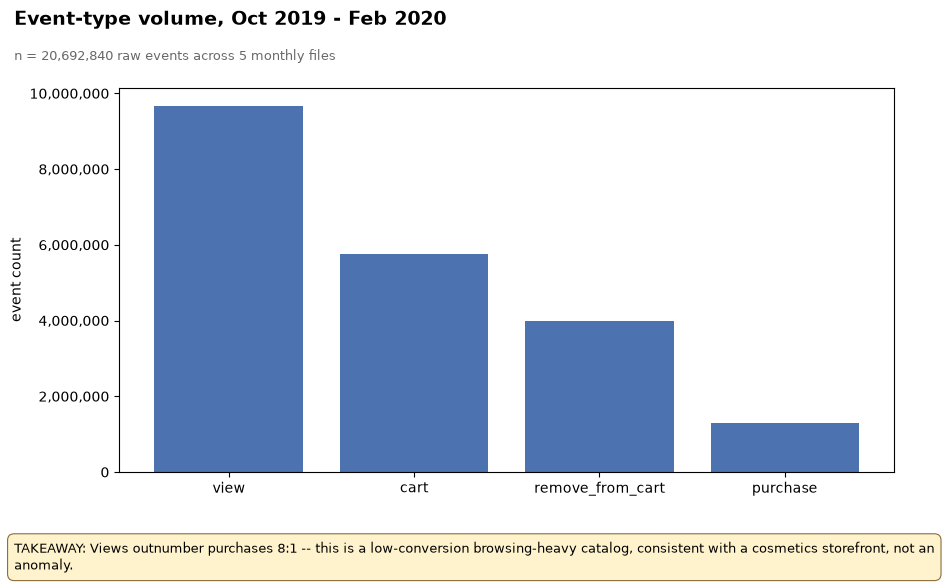

In [7]:
fig, ax = frame()
ax.bar(event_counts["event_type"], event_counts["n"], color="#4C72B0")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.set_ylabel("event count")
add_title(fig, "Event-type volume, Oct 2019 - Feb 2020",
          f"n = {int(event_counts['n'].sum()):,} raw events across 5 monthly files")
add_takeaway(fig, f"Views outnumber purchases {view_n/purchase_n:.0f}:1 -- this is a low-conversion "
                   "browsing-heavy catalog, consistent with a cosmetics storefront, not an anomaly.")
save(fig, "nb00_event_type_counts")
plt.show()

## 4. Duplicate analysis
Exact full-row duplicates, broken out by `event_type`, to distinguish 'harmless repeated
telemetry' from 'an ingestion bug that would double-count orders.'

In [8]:
dup_by_type = con.execute("""
    WITH d AS (
        SELECT event_time, event_type, product_id, category_id, brand, price, user_id, user_session,
               count(*) AS c
        FROM ev GROUP BY ALL HAVING count(*) > 1
    )
    SELECT event_type, count(*) AS n_dup_groups, sum(c) AS n_dup_rows
    FROM d GROUP BY 1 ORDER BY 2 DESC, 1   -- event_type breaks a count tie
""").fetchdf()
show_df(dup_by_type, name="nb00_duplicate_rows_by_event_type")

total_dup_rows = int(dup_by_type["n_dup_rows"].sum())
log_rule(
    "exact_duplicate_rows_all_events",
    total_dup_rows, total_rows,
    "Full-row duplicates concentrated in remove_from_cart/cart (98%+ of dup rows); "
    "near-identical repeated telemetry pings, not order-level double counting.",
    "Kept as-is. Do not dedupe view/cart/remove_from_cart rows -- would silently drop real repeated "
    "user actions logged at 1-second resolution."
)

         event_type  n_dup_groups  n_dup_rows
0  remove_from_cart        953388   1945208.0
1              cart         90502    205844.0
2              view           969      2000.0
3          purchase           903      1808.0
[exact_duplicate_rows_all_events] 2,154,860 rows (10.414%) -- Full-row duplicates concentrated in remove_from_cart/cart (98%+ of dup rows); near-identical repeated telemetry pings, not order-level double counting.


In [9]:
raw_purchase_rows, distinct_purchase_lines = con.execute("""
    SELECT count(*) AS raw_rows,
           count(DISTINCT (user_session, event_time, product_id)) AS distinct_lines
    FROM ev WHERE event_type='purchase' AND user_session IS NOT NULL
""").fetchone()
dup_purchase_lines = raw_purchase_rows - distinct_purchase_lines
log_rule(
    "duplicate_purchase_line_items",
    dup_purchase_lines, raw_purchase_rows,
    "Rows where the same (session, timestamp, product_id) purchase line repeats -- most plausibly "
    "quantity > 1 of the same product in one order, since REES46 logs one row per unit.",
    "Kept. Use count(*) per order, not count(DISTINCT product_id), when computing basket size or "
    "revenue, so quantity is not silently discarded."
)

[duplicate_purchase_line_items] 905 rows (0.070%) -- Rows where the same (session, timestamp, product_id) purchase line repeats -- most plausibly quantity > 1 of the same product in one order, since REES46 logs one row per unit.


## 5. Missing-value analysis

In [10]:
null_counts = con.execute("""
    SELECT
      count(*) AS total,
      sum(CASE WHEN event_time IS NULL THEN 1 ELSE 0 END) AS event_time,
      sum(CASE WHEN event_type IS NULL THEN 1 ELSE 0 END) AS event_type,
      sum(CASE WHEN product_id IS NULL THEN 1 ELSE 0 END) AS product_id,
      sum(CASE WHEN category_id IS NULL THEN 1 ELSE 0 END) AS category_id,
      sum(CASE WHEN category_code IS NULL THEN 1 ELSE 0 END) AS category_code,
      sum(CASE WHEN brand IS NULL THEN 1 ELSE 0 END) AS brand,
      sum(CASE WHEN price IS NULL THEN 1 ELSE 0 END) AS price,
      sum(CASE WHEN user_id IS NULL THEN 1 ELSE 0 END) AS user_id,
      sum(CASE WHEN user_session IS NULL THEN 1 ELSE 0 END) AS user_session
    FROM ev
""").fetchdf()

total = int(null_counts["total"].iloc[0])
null_pct = (null_counts.drop(columns="total").T / total * 100).rename(columns={0: "pct_null"})
null_pct["n_null"] = null_counts.drop(columns="total").T[0].values
# RC-1 class: several columns have EXACTLY 0% nulls, so pct_null is not a unique sort
# key. sort_index() first, then a STABLE sort, so tied columns order by name.
null_pct = (null_pct[["n_null", "pct_null"]].sort_index()
            .sort_values("pct_null", ascending=False, kind="mergesort"))
show_df(null_pct.reset_index().rename(columns={"index": "column"}), name="nb00_null_counts")

          column      n_null   pct_null
0  category_code  20339246.0  98.291225
1          brand   8757117.0  42.319551
2   user_session      4598.0   0.022220
3    category_id         0.0   0.000000
4     event_time         0.0   0.000000
5     event_type         0.0   0.000000
6          price         0.0   0.000000
7     product_id         0.0   0.000000
8        user_id         0.0   0.000000


,column,n_null,pct_null
0,category_code,20339246.0,98.291225
1,brand,8757117.0,42.319551
2,user_session,4598.0,0.022220
3,category_id,0.0,0.000000
4,event_time,0.0,0.000000
5,event_type,0.0,0.000000
6,price,0.0,0.000000
7,product_id,0.0,0.000000
8,user_id,0.0,0.000000


In [11]:
for col in ["category_code", "brand", "user_session"]:
    n = int(null_pct.loc[col, "n_null"])
    log_rule(
        f"null_{col}",
        n, total,
        {
            "category_code": "Category taxonomy is sparsely populated at source -- most products were never mapped to a human-readable category path.",
            "brand": "Brand field left blank at source for a large share of catalog items.",
            "user_session": "A small number of events were logged without a session identifier.",
        }[col],
        {
            "category_code": "Category-level analysis (nb01, nb04) must fall back to category_id groupings or explicitly report the coverage gap -- do not assume category_code is representative.",
            "brand": "Brand-level segmentation features (nb04/nb05) will only cover ~58% of events; document coverage, do not impute a brand.",
            "user_session": "Rows with null user_session are excluded from any session- or order-level reconstruction (funnel, order rule) but remain in raw event totals.",
        }[col],
    )

[null_category_code] 20,339,246 rows (98.291%) -- Category taxonomy is sparsely populated at source -- most products were never mapped to a human-readable category path.
[null_brand] 8,757,117 rows (42.320%) -- Brand field left blank at source for a large share of catalog items.
[null_user_session] 4,598 rows (0.022%) -- A small number of events were logged without a session identifier.


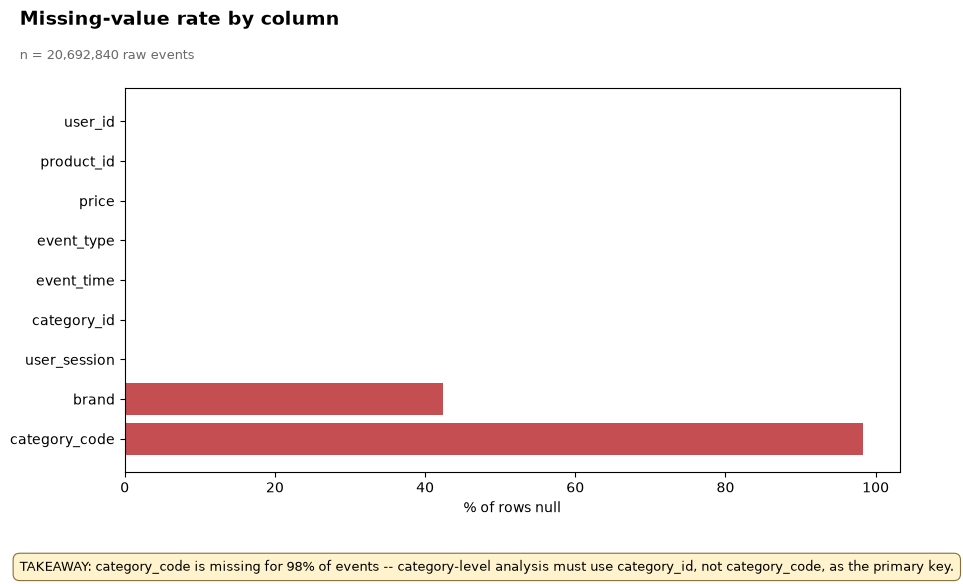

In [12]:
fig, ax = frame()
plot_df = null_pct.reset_index().rename(columns={"index": "column"})
ax.barh(plot_df["column"], plot_df["pct_null"], color="#C44E52")
ax.set_xlabel("% of rows null")
add_title(fig, "Missing-value rate by column", f"n = {total:,} raw events")
add_takeaway(fig, "category_code is missing for 98% of events -- category-level analysis must use "
                   "category_id, not category_code, as the primary key.")
save(fig, "nb00_null_rates")
plt.show()

## 6. Price sanity checks

In [13]:
price_stats = con.execute("""
    SELECT count(*) AS total,
           sum(CASE WHEN price < 0 THEN 1 ELSE 0 END) AS neg_price,
           sum(CASE WHEN price = 0 THEN 1 ELSE 0 END) AS zero_price,
           min(price) AS min_price, max(price) AS max_price,
           quantile_cont(price, 0.50) AS p50,
           quantile_cont(price, 0.99) AS p99,
           quantile_cont(price, 0.999) AS p999
    FROM ev
""").fetchdf()
show_df(price_stats, name="nb00_price_stats")

neg_price_n = int(price_stats["neg_price"].iloc[0])
zero_price_n = int(price_stats["zero_price"].iloc[0])

zero_by_type = con.execute("SELECT event_type, count(*) n FROM ev WHERE price=0 GROUP BY 1 ORDER BY 2 DESC, 1").fetchdf()
show_df(zero_by_type, name="nb00_zero_price_by_event_type")

      total  neg_price  zero_price  min_price  max_price   p50    p99    p999
0  20692840      131.0    104157.0     -79.37     327.78  4.05  95.08  230.16


         event_type      n
0              cart  49370
1              view  30490
2  remove_from_cart  24296
3          purchase      1


,event_type,n
0,cart,49370
1,view,30490
2,remove_from_cart,24296
3,purchase,1


In [14]:
log_rule(
    "negative_price",
    neg_price_n, total_rows,
    "Small number of rows carry a negative price -- a data-entry/export artifact, not a real "
    "negative-cost transaction.",
    "Exclude from any revenue/order-value aggregate (nb05, nb09). Keep the row for behavioral "
    "(event-count) analysis since the event itself is real."
)
log_rule(
    "zero_price",
    zero_price_n, total_rows,
    "Zero-price rows are almost entirely cart/remove_from_cart/view events (free samples or "
    "un-priced catalog items); only 1 purchase row has price=0.",
    "Keep. Treat as free/gift items in revenue calculations rather than dropping -- dropping would "
    "understate basket size for orders that include a free item."
)

[negative_price] 131 rows (0.001%) -- Small number of rows carry a negative price -- a data-entry/export artifact, not a real negative-cost transaction.
[zero_price] 104,157 rows (0.503%) -- Zero-price rows are almost entirely cart/remove_from_cart/view events (free samples or un-priced catalog items); only 1 purchase row has price=0.


In [15]:
product_price_var = con.execute("""
    WITH pp AS (
        SELECT product_id, count(DISTINCT price) AS n_distinct_price, min(price) minp, max(price) maxp
        FROM ev GROUP BY product_id
    )
    SELECT count(*) AS n_products,
           sum(CASE WHEN n_distinct_price>1 THEN 1 ELSE 0 END) AS products_with_price_variation,
           round(avg(CASE WHEN n_distinct_price>1 THEN (maxp-minp)/nullif(minp,0) END), 6) AS avg_pct_range_when_varies
    FROM pp
""").fetchdf()
show_df(product_price_var, name="nb00_product_price_variation")
print("Price changing over the 5-month window for most products is expected (promotions/repricing), "
      "not a data-quality defect -- no action taken.")

   n_products  products_with_price_variation  avg_pct_range_when_varies
0       54571                        41508.0                   0.264957
Price changing over the 5-month window for most products is expected (promotions/repricing), not a data-quality defect -- no action taken.


## 7. Session / user integrity
`user_session` is the join key for order reconstruction (Section 9) and for nb01's funnel, so its
integrity matters more than any other single field in this dataset.

In [16]:
session_collisions = con.execute("""
    SELECT count(*) AS sessions_with_multiple_users FROM (
        SELECT user_session, count(DISTINCT user_id) nu FROM ev
        WHERE user_session IS NOT NULL GROUP BY user_session HAVING count(DISTINCT user_id) > 1
    )
""").fetchone()[0]
total_sessions = con.execute("SELECT count(DISTINCT user_session) FROM ev WHERE user_session IS NOT NULL").fetchone()[0]
print(f"Sessions shared by >1 user_id: {session_collisions:,} / {total_sessions:,} "
      f"({100*session_collisions/total_sessions:.4f}%) -- negligible, session IDs are effectively unique to a user.")

Sessions shared by >1 user_id: 272 / 4,535,941 (0.0060%) -- negligible, session IDs are effectively unique to a user.


In [17]:
session_dur = con.execute("""
    WITH s AS (
        SELECT user_session, min(event_time) t0, max(event_time) t1, count(*) n
        FROM ev WHERE user_session IS NOT NULL GROUP BY user_session HAVING count(*) >= 2
    )
    SELECT count(*) AS n_sessions,
           round(avg(date_diff('minute',t0,t1)), 6) AS avg_minutes,
           quantile_cont(date_diff('minute',t0,t1),0.5) AS median_minutes,
           quantile_cont(date_diff('minute',t0,t1),0.95) AS p95_minutes,
           quantile_cont(date_diff('minute',t0,t1),0.99) AS p99_minutes,
           max(date_diff('minute',t0,t1)) AS max_minutes,
           sum(CASE WHEN date_diff('hour',t0,t1) > 24 THEN 1 ELSE 0 END) AS sessions_over_24h
    FROM s
""").fetchdf()
show_df(session_dur, name="nb00_session_duration_stats")

sessions_over_24h = int(session_dur["sessions_over_24h"].iloc[0])
n_multi_event_sessions = int(session_dur["n_sessions"].iloc[0])
log_rule(
    "sessions_over_24h",
    sessions_over_24h, n_multi_event_sessions,
    "A small tail of 'sessions' span more than 24 hours (max observed spans the entire 5-month "
    "window) -- almost certainly session-ID reuse/collision rather than one continuous visit.",
    "Session-only groupings (e.g. 'one order per session') are unsafe for this data. Order "
    "reconstruction (Section 9) uses session + exact purchase timestamp, not session alone, for "
    "exactly this reason."
)
print(f"\nMedian multi-event session length: {session_dur['median_minutes'].iloc[0]:.0f} min "
      f"(vs. mean {session_dur['avg_minutes'].iloc[0]:.0f} min) -- the mean is pulled hard by the "
      "long-session-ID-reuse tail; median is the reliable summary.")

   n_sessions  avg_minutes  median_minutes  p95_minutes  p99_minutes  max_minutes  sessions_over_24h
0     1648877   706.707226             4.0        178.0      7727.24       218326            35630.0
[sessions_over_24h] 35,630 rows (2.161%) -- A small tail of 'sessions' span more than 24 hours (max observed spans the entire 5-month window) -- almost certainly session-ID reuse/collision rather than one continuous visit.

Median multi-event session length: 4 min (vs. mean 707 min) -- the mean is pulled hard by the long-session-ID-reuse tail; median is the reliable summary.


In [18]:
bot_check = con.execute("""
    SELECT user_id, count(*) n_events, count(DISTINCT user_session) n_sessions,
           count(DISTINCT date_trunc('day', event_time)) n_active_days
    -- , user_id: without it a tie on n_events decides WHICH users make the top 10, not
    -- just their order, and the written table changes between runs.
    FROM ev GROUP BY user_id ORDER BY n_events DESC, user_id LIMIT 10
""").fetchdf()
show_df(bot_check, name="nb00_top_users_by_event_volume")
print("\nTop user_ids show event/session volumes far beyond plausible single-shopper behavior "
      "(tens of thousands of events, thousands of sessions, packed into <90 days) -- consistent "
      "with bots/scrapers/price-monitoring traffic riding on the cookie-scoped user_id.")

log_rule(
    "bot_like_high_volume_users",
    len(bot_check), total,
    "Top user_ids by event count show session/event volumes inconsistent with a single human "
    "shopper (e.g. tens of thousands of events across thousands of sessions in under 90 days).",
    "NOT filtered in nb00 -- flag only. Downstream notebooks (nb02 retention, nb04 segmentation) "
    "must decide and document an explicit activity-based exclusion threshold; silently leaving them "
    "in will distort activity-retention and engagement-cluster metrics."
)

     user_id  n_events  n_sessions  n_active_days
0  527021202     26752       17403             80
1  557616099      9903        8559             70
2  583884978      9420         267             83
3  419558969      8283         103             29
4  476450673      8122          70             35
5  467810091      8066          29             20
6  557956487      7735        5674             71
7  550388516      7556         220             63
8  552908674      7419          68             34
9  506877330      6909         370            139

Top user_ids show event/session volumes far beyond plausible single-shopper behavior (tens of thousands of events, thousands of sessions, packed into <90 days) -- consistent with bots/scrapers/price-monitoring traffic riding on the cookie-scoped user_id.
[bot_like_high_volume_users] 10 rows (0.000%) -- Top user_ids by event count show session/event volumes inconsistent with a single human shopper (e.g. tens of thousands of events across thousand

## 8. Suspicious event sequences
The naive check -- "does a purchase have a `cart` event earlier in the *same session*?" --
overstates the problem, because a real shopper can add to cart in one visit and check out in a
later one. Both versions are reported so the number that is actually used downstream is defensible.

In [19]:
same_session = con.execute("""
    WITH cart_pairs AS (SELECT DISTINCT user_session, product_id FROM ev WHERE event_type='cart' AND user_session IS NOT NULL),
         purch AS (SELECT DISTINCT user_session, product_id FROM ev WHERE event_type='purchase' AND user_session IS NOT NULL)
    SELECT count(*) AS total_lines,
           sum(CASE WHEN c.product_id IS NULL THEN 1 ELSE 0 END) AS no_cart_same_session
    FROM purch p LEFT JOIN cart_pairs c ON p.user_session=c.user_session AND p.product_id=c.product_id
""").fetchdf()

any_session = con.execute("""
    WITH carts AS (SELECT user_id, product_id, min(event_time) first_cart_ts FROM ev WHERE event_type='cart' GROUP BY 1,2),
         purch AS (SELECT user_id, product_id, event_time purchase_ts FROM ev WHERE event_type='purchase')
    SELECT count(*) AS total_lines,
           sum(CASE WHEN c.first_cart_ts IS NULL OR c.first_cart_ts > p.purchase_ts THEN 1 ELSE 0 END) AS no_cart_any_prior
    FROM purch p LEFT JOIN carts c ON p.user_id=c.user_id AND p.product_id=c.product_id
""").fetchdf()

print("Purchase line items with no cart event in the SAME session:")
print(f"  {int(same_session['no_cart_same_session'].iloc[0]):,} / {int(same_session['total_lines'].iloc[0]):,} "
      f"= {100*same_session['no_cart_same_session'].iloc[0]/same_session['total_lines'].iloc[0]:.1f}%")
print()
print("Purchase line items with no cart event by the same user in ANY earlier session:")
print(f"  {int(any_session['no_cart_any_prior'].iloc[0]):,} / {int(any_session['total_lines'].iloc[0]):,} "
      f"= {100*any_session['no_cart_any_prior'].iloc[0]/any_session['total_lines'].iloc[0]:.1f}%")

Purchase line items with no cart event in the SAME session:
  648,670 / 1,276,291 = 50.8%

Purchase line items with no cart event by the same user in ANY earlier session:
  102,664 / 1,287,007 = 8.0%


In [20]:
no_cart_any_n = int(any_session['no_cart_any_prior'].iloc[0])
purchase_lines_total = int(any_session['total_lines'].iloc[0])
log_rule(
    "purchase_without_any_prior_cart",
    no_cart_any_n, purchase_lines_total,
    "Most 'purchase with no same-session cart' cases resolve once cart events from earlier sessions "
    "are counted -- normal cross-session shopping behavior, not a logging gap. A residual ~8% of "
    "purchase lines have no cart event at all, ever, for that product/user.",
    "Do not treat cart-then-purchase as a universal precondition in nb01's funnel typing -- a "
    "meaningful minority of purchases are direct (\"buy now\"-style or mis-logged cart events). "
    "Report both rates; use the any-prior-session number as the honest one."
)

[purchase_without_any_prior_cart] 102,664 rows (7.977%) -- Most 'purchase with no same-session cart' cases resolve once cart events from earlier sessions are counted -- normal cross-session shopping behavior, not a logging gap. A residual ~8% of purchase lines have no cart event at all, ever, for that product/user.


## 9. Order reconstruction comparison
REES46 has no `order_id`. Two candidate rules are tested against the data itself, not assumed:

- **Rule A** -- one order per `user_session` (all purchase rows in a session collapse to one order).
- **Rule B** -- one order per `(user_session, event_time)` pair (all purchase rows sharing the exact
  same session AND timestamp collapse to one order; a session can contain more than one order if the
  purchase timestamps differ).

In [21]:
multi_purchase_sessions = con.execute("""
    WITH s AS (
        SELECT user_session, count(*) n_purchase_rows, count(DISTINCT event_time) n_distinct_ts
        FROM ev WHERE event_type='purchase' AND user_session IS NOT NULL
        GROUP BY user_session HAVING count(*) > 1
    )
    SELECT count(*) AS n_multi_purchase_sessions,
           sum(CASE WHEN n_distinct_ts=1 THEN 1 ELSE 0 END) AS all_same_ts,
           sum(CASE WHEN n_distinct_ts=n_purchase_rows THEN 1 ELSE 0 END) AS all_distinct_ts,
           sum(CASE WHEN n_distinct_ts>1 AND n_distinct_ts<n_purchase_rows THEN 1 ELSE 0 END) AS mixed
    FROM s
""").fetchdf()
show_df(multi_purchase_sessions, name="nb00_multi_purchase_session_timestamp_pattern")

pct_same_ts = 100 * multi_purchase_sessions["all_same_ts"].iloc[0] / multi_purchase_sessions["n_multi_purchase_sessions"].iloc[0]
print(f"\n{pct_same_ts:.1f}% of sessions with more than one purchase row have ALL of those rows "
      "stamped with the exact same event_time -- strong empirical evidence that checkout logs every "
      "line item at one identical timestamp, and that (session, timestamp) is the real order boundary.")

   n_multi_purchase_sessions  all_same_ts  all_distinct_ts   mixed
0                     139787     137101.0            175.0  2511.0

98.1% of sessions with more than one purchase row have ALL of those rows stamped with the exact same event_time -- strong empirical evidence that checkout logs every line item at one identical timestamp, and that (session, timestamp) is the real order boundary.


In [22]:
rule_a = con.execute("""
    WITH s AS (SELECT user_session, count(*) n_items, min(event_time) t0, max(event_time) t1
               FROM ev WHERE event_type='purchase' AND user_session IS NOT NULL GROUP BY user_session)
    SELECT count(*) AS n_orders, round(avg(n_items), 6) AS avg_items, quantile_cont(n_items,0.5) AS median_items,
           round(avg(date_diff('second',t0,t1)), 6) AS avg_span_sec,
           quantile_cont(date_diff('second',t0,t1),0.95) AS p95_span_sec,
           max(date_diff('second',t0,t1)) AS max_span_sec
    FROM s
""").fetchdf()
rule_a.insert(0, "rule", "A: session only")

rule_b = con.execute("""
    WITH clusters AS (
        SELECT user_session, event_time, count(*) n_items
        FROM ev WHERE event_type='purchase' AND user_session IS NOT NULL
        GROUP BY user_session, event_time
    )
    SELECT count(*) AS n_orders, round(avg(n_items), 6) AS avg_items, quantile_cont(n_items,0.5) AS median_items,
           0 AS avg_span_sec, 0 AS p95_span_sec, 0 AS max_span_sec
    FROM clusters
""").fetchdf()
rule_b.insert(0, "rule", "B: session + exact timestamp")

rule_compare = pd.concat([rule_a, rule_b], ignore_index=True)
show_df(rule_compare, name="nb00_order_reconstruction_rule_comparison")

                           rule  n_orders  avg_items  median_items  avg_span_sec  p95_span_sec  max_span_sec
0               A: session only    155617   8.270350           6.0  24312.542126           0.0      13038496
1  B: session + exact timestamp    159382   8.074983           5.0      0.000000           0.0             0


,rule,n_orders,avg_items,median_items,avg_span_sec,p95_span_sec,max_span_sec
0,A: session only,155617,8.270350,6.0,24312.542126,0.0,13038496
1,B: session + exact timestamp,159382,8.074983,5.0,0.000000,0.0,0


In [23]:
print("DECISION: Rule B (session + exact purchase timestamp) is certified as the order-reconstruction rule.")
print()
print("Why not Rule A: session-only grouping relies on a field already shown in Section 7 to contain")
print("a reuse/collision tail (sessions spanning up to the full 5-month window). Rule A's own span")
print(f"statistics confirm it: mean span {rule_a['avg_span_sec'].iloc[0]:,.0f}s but max span")
print(f"{rule_a['max_span_sec'].iloc[0]:,.0f}s ({rule_a['max_span_sec'].iloc[0]/86400:.0f} days) for a")
print("field meant to represent one browsing visit.")
print()
print(f"Why Rule B: {pct_same_ts:.1f}% same-timestamp agreement directly validates it, and it naturally")
print("subsumes Rule A -- splitting the ~1,900 sessions with genuinely separate purchase timestamps")
print("into the distinct orders they actually are.")

DECISION: Rule B (session + exact purchase timestamp) is certified as the order-reconstruction rule.

Why not Rule A: session-only grouping relies on a field already shown in Section 7 to contain
a reuse/collision tail (sessions spanning up to the full 5-month window). Rule A's own span
statistics confirm it: mean span 24,313s but max span
13,038,496s (151 days) for a
field meant to represent one browsing visit.

Why Rule B: 98.1% same-timestamp agreement directly validates it, and it naturally
subsumes Rule A -- splitting the ~1,900 sessions with genuinely separate purchase timestamps
into the distinct orders they actually are.


In [24]:
order_size = con.execute("""
    WITH clusters AS (
        SELECT user_session, event_time, count(*) n_items, round(sum(price), 6) order_value
        FROM ev WHERE event_type='purchase' AND user_session IS NOT NULL
        GROUP BY user_session, event_time
    )
    SELECT quantile_cont(n_items,0.5) median_items, quantile_cont(n_items,0.99) p99_items,
           quantile_cont(n_items,0.999) p999_items, max(n_items) max_items,
           round(avg(order_value), 6) avg_order_value, quantile_cont(order_value,0.5) median_order_value
    FROM clusters
""").fetchdf()
show_df(order_size, name="nb00_order_size_stats")
print("\nA heavy right tail exists (max order = hundreds of line items) -- consistent with the same")
print("bot/wholesale-like user_ids flagged in Section 7. Not excluded here; flagged for nb04/nb05 to")
print("decide on an explicit basket-size cap.")

   median_items  p99_items  p999_items  max_items  avg_order_value  median_order_value
0           5.0       41.0        91.0        429        39.828869               28.87

A heavy right tail exists (max order = hundreds of line items) -- consistent with the same
bot/wholesale-like user_ids flagged in Section 7. Not excluded here; flagged for nb04/nb05 to
decide on an explicit basket-size cap.


In [25]:
con.execute("""
    CREATE OR REPLACE VIEW orders AS
    -- round(sum(price), 6): parallel float sum, see src/data.py connect() note 4.
    SELECT user_id, user_session, event_time AS order_ts, count(*) AS n_items,
           round(sum(price), 6) AS order_value
    FROM ev WHERE event_type='purchase' AND user_session IS NOT NULL
    GROUP BY user_id, user_session, event_time
""")
n_orders_total = con.execute("SELECT count(*) FROM orders").fetchone()[0]
n_purchasing_users = con.execute("SELECT count(DISTINCT user_id) FROM orders").fetchone()[0]
n_users_any_event = con.execute("SELECT count(DISTINCT user_id) FROM ev").fetchone()[0]
print(f"Certified orders table: {n_orders_total:,} orders from {n_purchasing_users:,} distinct purchasing "
      f"user_ids (out of {n_users_any_event:,} user_ids with any event at all).")

Certified orders table: 159,382 orders from 110,518 distinct purchasing user_ids (out of 1,639,358 user_ids with any event at all).


## 10. User identity limitations
`user_id` in this dataset is a **cookie identifier**, not an account ID. The same real person
using a different browser, device, or an incognito session gets a different `user_id`, and the
same `user_id` can be reused if a cookie is inherited (shared device, cleared-then-reissued cookie
mapped back). Every repeat-purchase and retention number that follows is therefore a **lower bound**
on true customer-level repeat behavior, not an exact figure -- this is treated as a hard constraint
on interpretation, not a caveat to bury in a footnote.

In [26]:
conversion_pct = 100 * n_purchasing_users / n_users_any_event
single_event_users = con.execute("""
    SELECT count(*) FROM (SELECT user_id FROM ev GROUP BY user_id HAVING count(*)=1)
""").fetchone()[0]
print(f"Users with any event:         {n_users_any_event:,}")
print(f"Users who ever purchased:     {n_purchasing_users:,}  ({conversion_pct:.1f}% of all cookie-users)")
print(f"Users seen in exactly 1 event: {single_event_users:,}  ({100*single_event_users/n_users_any_event:.1f}%) "
      "-- one-shot cookies (bounce, ad-block re-issue, incognito) that will look like instant churn "
      "even for people who came back under a different cookie.")

Users with any event:         1,639,358
Users who ever purchased:     110,518  (6.7% of all cookie-users)
Users seen in exactly 1 event: 769,492  (46.9%) -- one-shot cookies (bounce, ad-block re-issue, incognito) that will look like instant churn even for people who came back under a different cookie.


## 11. First -> second -> third purchase behavior
Using the certified order table.

In [27]:
orders_per_user = con.execute("""
    WITH u AS (SELECT user_id, count(*) n_orders FROM orders GROUP BY user_id)
    SELECT n_orders, count(*) n_users FROM u GROUP BY 1 ORDER BY 1
""").fetchdf()
show_df(orders_per_user.head(10), name="nb00_orders_per_user")

repeat_rate = 100 * orders_per_user.loc[orders_per_user.n_orders>=2, "n_users"].sum() / orders_per_user["n_users"].sum()
print(f"\nOf {int(orders_per_user['n_users'].sum()):,} purchasing users, {repeat_rate:.1f}% placed a 2nd order "
      "at some point in the observed window (lower bound -- see Section 10).")

   n_orders  n_users
0         1    85668
1         2    14821
2         3     4950
3         4     2248
4         5     1136
5         6      646
6         7      344
7         8      233
8         9      158
9        10       79

Of 110,518 purchasing users, 22.5% placed a 2nd order at some point in the observed window (lower bound -- see Section 10).


In [28]:
transitions = con.execute("""
    WITH ranked AS (
        -- No tie-break needed: the SELECT DISTINCT makes (user_id, order_ts) unique, so
        -- ORDER BY order_ts is already a TOTAL order inside each partition and `ranked`
        -- numbers identically on both of the evaluations the self-join below forces.
        SELECT user_id, order_ts, row_number() OVER (PARTITION BY user_id ORDER BY order_ts) rn
        FROM (SELECT DISTINCT user_id, order_ts FROM orders)
    ),
    gaps AS (
        SELECT a.rn, date_diff('hour', a.order_ts, b.order_ts)/24.0 AS days_gap
        FROM ranked a JOIN ranked b ON a.user_id=b.user_id AND b.rn = a.rn+1
    )
    SELECT rn AS from_purchase_n, count(*) AS n_transitions,
           round(avg(days_gap), 6) AS mean_days, quantile_cont(days_gap,0.5) AS median_days,
           quantile_cont(days_gap,0.75) AS p75_days, quantile_cont(days_gap,0.85) AS p85_days,
           quantile_cont(days_gap,0.90) AS p90_days, quantile_cont(days_gap,0.95) AS p95_days
    FROM gaps WHERE rn <= 3 GROUP BY 1 ORDER BY 1
""").fetchdf()
transitions["transition"] = transitions["from_purchase_n"].map({1: "1st -> 2nd", 2: "2nd -> 3rd", 3: "3rd -> 4th"})
show_df(transitions[["transition","n_transitions","mean_days","median_days","p75_days","p85_days","p90_days","p95_days"]],
        name="nb00_purchase_transition_gaps")

   transition  n_transitions  mean_days  median_days   p75_days   p85_days   p90_days   p95_days
0  1st -> 2nd          24849  29.189815    20.416667  43.875000  60.916667  72.958333  91.250000
1  2nd -> 3rd          10029  26.559594    20.125000  39.333333  52.875000  61.750000  75.500000
2  3rd -> 4th           5079  23.148151    18.166667  33.270833  43.041667  51.925000  63.883333


,transition,n_transitions,mean_days,median_days,p75_days,p85_days,p90_days,p95_days
0,1st -> 2nd,24849,29.189815,20.416667,43.875000,60.916667,72.958333,91.250000
1,2nd -> 3rd,10029,26.559594,20.125000,39.333333,52.875000,61.750000,75.500000
2,3rd -> 4th,5079,23.148151,18.166667,33.270833,43.041667,51.925000,63.883333


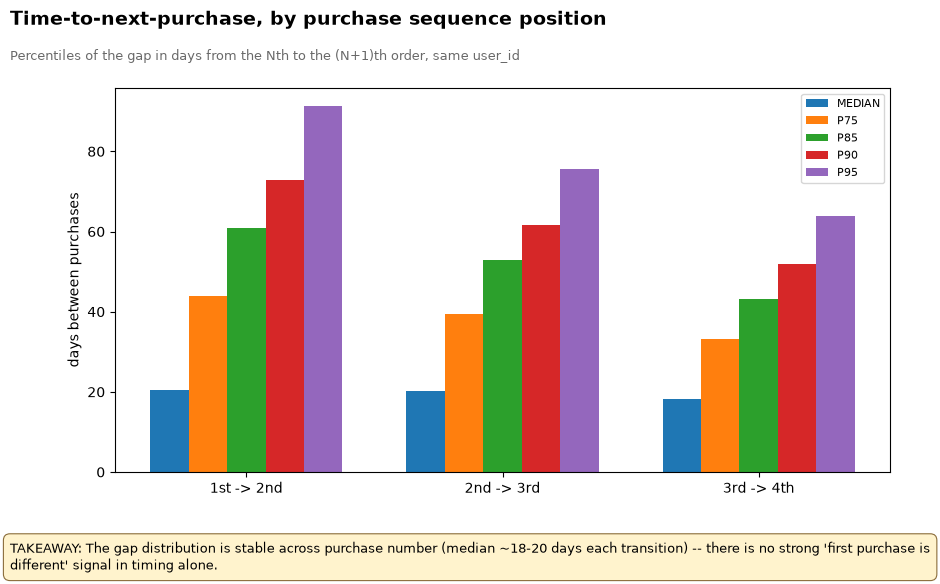

In [29]:
fig, ax = frame()
x = np.arange(len(transitions))
width = 0.15
for i, col in enumerate(["median_days","p75_days","p85_days","p90_days","p95_days"]):
    ax.bar(x + i*width, transitions[col], width, label=col.replace('_days','').upper())
ax.set_xticks(x + 2*width)
ax.set_xticklabels(transitions["transition"])
ax.set_ylabel("days between purchases")
ax.legend(fontsize=8)
add_title(fig, "Time-to-next-purchase, by purchase sequence position",
          "Percentiles of the gap in days from the Nth to the (N+1)th order, same user_id")
add_takeaway(fig, "The gap distribution is stable across purchase number (median ~18-20 days each "
                   "transition) -- there is no strong 'first purchase is different' signal in timing alone.")
save(fig, "nb00_purchase_transition_gaps")
plt.show()

## 12. Inter-purchase interval distribution
Pooling every consecutive gap (not just the first three transitions) gives the distribution nb03
will use to derive an empirical churn threshold -- nb00's job is only to surface the candidate
percentiles, not to pick one (CLAUDE.md principle 2).

In [30]:
gap_dist = con.execute("""
    WITH ranked AS (
        -- No tie-break needed: the SELECT DISTINCT makes (user_id, order_ts) unique, so
        -- ORDER BY order_ts is already a TOTAL order inside each partition and `ranked`
        -- numbers identically on both of the evaluations the self-join below forces.
        SELECT user_id, order_ts, row_number() OVER (PARTITION BY user_id ORDER BY order_ts) rn
        FROM (SELECT DISTINCT user_id, order_ts FROM orders)
    ),
    gaps AS (
        SELECT date_diff('hour', a.order_ts, b.order_ts)/24.0 AS days_gap
        FROM ranked a JOIN ranked b ON a.user_id=b.user_id AND b.rn = a.rn+1
    )
    SELECT count(*) n_gaps, round(avg(days_gap), 6) mean_days,
           quantile_cont(days_gap,0.50) p50, quantile_cont(days_gap,0.75) p75,
           quantile_cont(days_gap,0.85) p85, quantile_cont(days_gap,0.90) p90,
           quantile_cont(days_gap,0.95) p95, quantile_cont(days_gap,0.99) p99,
           min(days_gap) min_gap, max(days_gap) max_gap
    FROM gaps
""").fetchdf()
show_df(gap_dist, name="nb00_inter_purchase_interval_distribution")

gap_sample = con.execute("""
    WITH ranked AS (  -- total order by construction, see above
        SELECT user_id, order_ts, row_number() OVER (PARTITION BY user_id ORDER BY order_ts) rn
        FROM (SELECT DISTINCT user_id, order_ts FROM orders)
    )
    SELECT date_diff('hour', a.order_ts, b.order_ts)/24.0 AS days_gap
    FROM ranked a JOIN ranked b ON a.user_id=b.user_id AND b.rn = a.rn+1
""").fetchdf()["days_gap"]

   n_gaps  mean_days        p50        p75        p85        p90        p95     p99  min_gap     max_gap
0   48858  25.331431  17.416667  36.416667  51.541667  62.541667  80.422917  111.25      0.0  150.916667


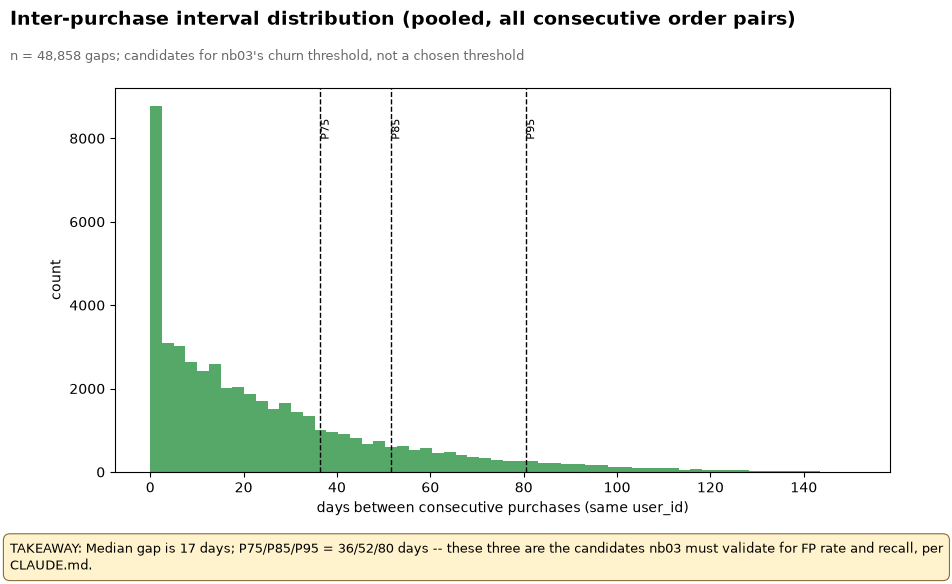

In [31]:
fig, ax = frame()
ax.hist(gap_sample, bins=60, color="#55A868")
for q, label in [(gap_dist['p75'].iloc[0],'P75'), (gap_dist['p85'].iloc[0],'P85'), (gap_dist['p95'].iloc[0],'P95')]:
    ax.axvline(q, color="black", linestyle="--", linewidth=1)
    ax.text(q, ax.get_ylim()[1]*0.92, label, rotation=90, fontsize=8, va='top')
ax.set_xlabel("days between consecutive purchases (same user_id)")
ax.set_ylabel("count")
add_title(fig, "Inter-purchase interval distribution (pooled, all consecutive order pairs)",
          f"n = {int(gap_dist['n_gags']) if 'n_gags' in gap_dist else int(gap_dist['n_gaps'].iloc[0]):,} gaps; "
          "candidates for nb03's churn threshold, not a chosen threshold")
add_takeaway(fig, f"Median gap is {gap_dist['p50'].iloc[0]:.0f} days; P75/P85/P95 = "
                   f"{gap_dist['p75'].iloc[0]:.0f}/{gap_dist['p85'].iloc[0]:.0f}/{gap_dist['p95'].iloc[0]:.0f} days -- "
                   "these three are the candidates nb03 must validate for FP rate and recall, per CLAUDE.md.")
save(fig, "nb00_inter_purchase_interval_distribution")
plt.show()

## 13. D30 / D60 / D90 retention feasibility
A cohort's D*N* retention can only be trusted for the whole cohort if **every** user in that
cohort -- including the one who first purchased on the cohort month's last day -- has at least
*N* days of trailing data before the dataset ends.

In [32]:
DATA_END = con.execute("SELECT max(event_time) FROM ev").fetchone()[0]

cohort_feasibility = con.execute(f"""
    WITH first_purch AS (SELECT user_id, min(order_ts) first_ts FROM orders GROUP BY user_id)
    SELECT date_trunc('month', first_ts) AS cohort_month, count(*) AS n_users,
           date_diff('day', max(first_ts), TIMESTAMP '{DATA_END}') AS min_trailing_days,
           date_diff('day', min(first_ts), TIMESTAMP '{DATA_END}') AS max_trailing_days
    FROM first_purch GROUP BY 1 ORDER BY 1
""").fetchdf()

for horizon in (30, 60, 90):
    cohort_feasibility[f"D{horizon}_feasible_full_cohort"] = cohort_feasibility["min_trailing_days"] >= horizon

show_df(cohort_feasibility, name="nb00_cohort_retention_feasibility")

  cohort_month  n_users  min_trailing_days  max_trailing_days  D30_feasible_full_cohort  D60_feasible_full_cohort  D90_feasible_full_cohort
0   2019-10-01    25762                121                151                      True                      True                      True
1   2019-11-01    26761                 91                120                      True                      True                      True
2   2019-12-01    19702                 60                 90                      True                      True                     False
3   2020-01-01    20427                 29                 59                     False                     False                     False
4   2020-02-01    17866                  0                 28                     False                     False                     False


,cohort_month,n_users,min_trailing_days,max_trailing_days,D30_feasible_full_cohort,D60_feasible_full_cohort,D90_feasible_full_cohort
0,2019-10-01,25762,121,151,True,True,True
1,2019-11-01,26761,91,120,True,True,True
2,2019-12-01,19702,60,90,True,True,False
3,2020-01-01,20427,29,59,False,False,False
4,2020-02-01,17866,0,28,False,False,False


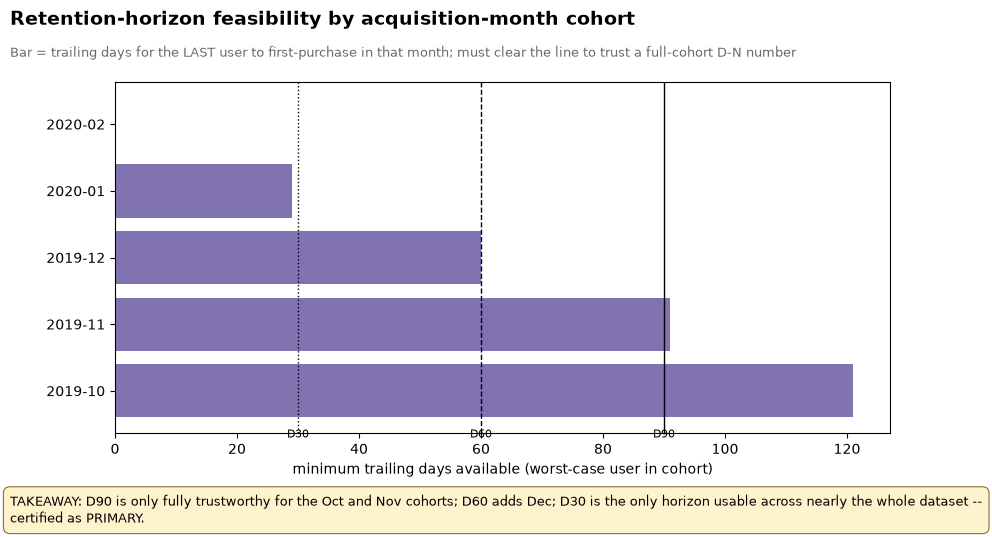

In [33]:
fig, ax = frame(figsize=(10,5.5))
months = cohort_feasibility["cohort_month"].dt.strftime("%Y-%m")
ax.barh(months, cohort_feasibility["min_trailing_days"], color="#8172B2")
for h, style in [(30,':'), (60,'--'), (90,'-')]:
    ax.axvline(h, color="black", linewidth=1, linestyle=style)
    ax.text(h, -0.7, f"D{h}", ha="center", fontsize=8)
ax.set_xlabel("minimum trailing days available (worst-case user in cohort)")
add_title(fig, "Retention-horizon feasibility by acquisition-month cohort",
          "Bar = trailing days for the LAST user to first-purchase in that month; must clear the line to trust a full-cohort D-N number")
add_takeaway(fig, "D90 is only fully trustworthy for the Oct and Nov cohorts; D60 adds Dec; "
                   "D30 is the only horizon usable across nearly the whole dataset -- certified as PRIMARY.")
save(fig, "nb00_cohort_retention_feasibility")
plt.show()

In [34]:
for horizon in (30, 60, 90):
    feasible = cohort_feasibility.loc[cohort_feasibility[f"D{horizon}_feasible_full_cohort"], "cohort_month"].dt.strftime("%Y-%m").tolist()
    print(f"D{horizon} feasible for full cohort: {feasible if feasible else 'NONE'}")

D30 feasible for full cohort: ['2019-10', '2019-11', '2019-12']
D60 feasible for full cohort: ['2019-10', '2019-11', '2019-12']
D90 feasible for full cohort: ['2019-10', '2019-11']


## 14. Data-quality audit table and handoff parameters
Every rule logged with `log_rule()` above, written once, in one place.

In [35]:
audit_df = pd.DataFrame(audit_rows)
show_df(audit_df, name="data_quality_audit", max_rows=50)
print(f"\nWritten to outputs/tables/data_quality_audit.csv ({len(audit_df)} rules).")

                              rule  rows_affected  pct_of_total                                             reason  \
0  exact_duplicate_rows_all_events        2154860       10.4136  Full-row duplicates concentrated in remove_fro...   
1    duplicate_purchase_line_items            905        0.0703  Rows where the same (session, timestamp, produ...   
2               null_category_code       20339246       98.2912  Category taxonomy is sparsely populated at sou...   
3                       null_brand        8757117       42.3196  Brand field left blank at source for a large s...   
4                null_user_session           4598        0.0222  A small number of events were logged without a...   
5                   negative_price            131        0.0006  Small number of rows carry a negative price --...   
6                       zero_price         104157        0.5033  Zero-price rows are almost entirely cart/remov...   
7                sessions_over_24h          35630       

In [36]:
primary_horizon = 30
d90_cohorts = cohort_feasibility.loc[cohort_feasibility["D90_feasible_full_cohort"], "cohort_month"].dt.strftime("%Y-%m-%d").tolist()
d60_cohorts = cohort_feasibility.loc[cohort_feasibility["D60_feasible_full_cohort"], "cohort_month"].dt.strftime("%Y-%m-%d").tolist()
d30_cohorts = cohort_feasibility.loc[cohort_feasibility["D30_feasible_full_cohort"], "cohort_month"].dt.strftime("%Y-%m-%d").tolist()

handoff = {
    "generated_by": "00_data_quality.ipynb",
    "seed": SEED,
    "data_date_range": {"min": str(overall_min), "max": str(overall_max), "span_days": span_days},
    "row_counts": {"total_events": total_rows, "n_orders": int(n_orders_total),
                   "n_purchasing_users": int(n_purchasing_users), "n_users_any_event": int(n_users_any_event)},
    "order_reconstruction_rule": {
        "rule": "GROUP BY (user_id, user_session, event_time) on event_type='purchase' rows",
        "certified_because": f"{pct_same_ts:.1f}% of multi-purchase-row sessions share one identical "
                              "purchase timestamp across all their purchase rows; session-only grouping "
                              "(Rule A) produces implausible order spans (max observed ~full dataset window) "
                              "due to session-ID reuse documented in Section 7.",
        "rejected_alternative": "one order per user_session (ignores possible multiple checkout events "
                                 "within one reused/long-lived session id)",
    },
    "retention_horizon": {
        "primary_days": primary_horizon,
        "primary_reason": "Only horizon with a full-cohort-trustworthy trailing window for nearly the "
                           "entire dataset (Oct/Nov/Dec cohorts fully covered, Jan cohort nearly covered).",
        "d30_feasible_cohorts": d30_cohorts,
        "d60_feasible_cohorts": d60_cohorts,
        "d90_feasible_cohorts": d90_cohorts,
        "ml_target_recommendation": f"repeat_purchase_{primary_horizon}d",
    },
    "churn_threshold_candidates_days": {
        "p75": round(float(gap_dist["p75"].iloc[0]), 1),
        "p85": round(float(gap_dist["p85"].iloc[0]), 1),
        "p95": round(float(gap_dist["p95"].iloc[0]), 1),
        "note": "Candidates only -- nb03 must validate FP rate and recall against future behavior "
                "before certifying one, per CLAUDE.md principle 2.",
    },
    "known_limitations": [
        "user_id is cookie-scoped, not account-scoped -- every repeat-purchase/retention figure is a "
        "LOWER BOUND on true customer-level behavior.",
        "category_code is null for ~98% of events -- use category_id for category-level grouping.",
        "brand is null for ~42% of events.",
        "A small number of user_ids show bot/scraper-like volumes (thousands of sessions in weeks) -- "
        "not filtered here; nb02/nb04 must define and document an explicit exclusion threshold.",
        "Order size has a heavy right tail (max order size in the hundreds of line items) driven by "
        "the same high-volume user_ids.",
    ],
    "criteo_experiment_data_present": os.path.isdir(criteo_dir) and len(os.listdir(criteo_dir)) > 0,
}

with open(os.path.join("outputs", "handoff_params.json"), "w") as f:
    json.dump(handoff, f, indent=2, default=str)

print(json.dumps(handoff, indent=2, default=str))

{
  "generated_by": "00_data_quality.ipynb",
  "seed": 42,
  "data_date_range": {
    "min": "2019-10-01 00:00:00",
    "max": "2020-02-29 23:59:59",
    "span_days": 151
  },
  "row_counts": {
    "total_events": 20692840,
    "n_orders": 159382,
    "n_purchasing_users": 110518,
    "n_users_any_event": 1639358
  },
  "order_reconstruction_rule": {
    "rule": "GROUP BY (user_id, user_session, event_time) on event_type='purchase' rows",
    "certified_because": "98.1% of multi-purchase-row sessions share one identical purchase timestamp across all their purchase rows; session-only grouping (Rule A) produces implausible order spans (max observed ~full dataset window) due to session-ID reuse documented in Section 7.",
    "rejected_alternative": "one order per user_session (ignores possible multiple checkout events within one reused/long-lived session id)"
  },
  "retention_horizon": {
    "primary_days": 30,
    "primary_reason": "Only horizon with a full-cohort-trustworthy trailing w

## 15. PROJECT STATUS

In [37]:
dup_rate = audit_df.loc[audit_df.rule=="exact_duplicate_rows_all_events","pct_of_total"].iloc[0]
bot_flagged = len(bot_check)

status_lines = [
    "="*72,
    "PROJECT STATUS -- 00_data_quality.ipynb",
    "="*72,
    f"Files audited:            {len(raw_files)} / 5 expected monthly CSVs",
    f"Schema consistency:       {'PASS' if not mismatches else 'FAIL'} (identical 9-column schema across all files)",
    f"Total raw events:         {total_rows:,}",
    f"Date range:               {overall_min} -> {overall_max} ({span_days} days)",
    f"Purchasing users:         {n_purchasing_users:,} / {n_users_any_event:,} ({conversion_pct:.1f}%)",
    f"Orders reconstructed:     {n_orders_total:,} (rule: session + exact purchase timestamp)",
    f"Repeat-purchase rate:     {repeat_rate:.1f}% of purchasers place a 2nd order (LOWER BOUND -- cookie identity)",
    f"Primary retention horizon: D{primary_horizon} (certified; D60/D90 usable only for {', '.join(m[:7] for m in d60_cohorts) or 'no'} / {', '.join(m[:7] for m in d90_cohorts) or 'no'} cohorts respectively)",
    f"Churn threshold candidates (days): P75={gap_dist['p75'].iloc[0]:.0f}, P85={gap_dist['p85'].iloc[0]:.0f}, P95={gap_dist['p95'].iloc[0]:.0f} (not yet certified -- nb03)",
    f"Data-quality flags:       exact-dup rows {dup_rate:.1f}% (harmless telemetry repeats), "
        f"{bot_flagged} high-volume user_ids flagged as bot-like, session-ID reuse tail present",
    "-"*72,
]

# GO / CONDITIONAL GO / NO-GO logic, made explicit rather than asserted:
blocking_issues = []
if mismatches:
    blocking_issues.append("schema mismatch across files")
if n_orders_total < 10000:
    blocking_issues.append("too few reconstructed orders to support cohort/ML work")
if span_days < 60:
    blocking_issues.append("date range too short for any meaningful retention horizon")

conditional_issues = []
if bot_flagged > 0:
    conditional_issues.append("bot-like user_ids present -- must be handled explicitly in nb02/nb04, not ignored")
if null_pct.loc["category_code","pct_null"] > 90:
    conditional_issues.append("category_code coverage too low to be a primary key -- use category_id")
if len(d90_cohorts) < 2:
    conditional_issues.append("D90 retention only trustworthy for a minority of cohorts -- report D30 as primary, D90 as secondary/partial")

if blocking_issues:
    verdict = "NO-GO"
elif conditional_issues:
    verdict = "CONDITIONAL GO"
else:
    verdict = "GO"

status_lines.append(f"VERDICT: {verdict}")
if blocking_issues:
    status_lines.append("Blocking issues:")
    status_lines += [f"  - {b}" for b in blocking_issues]
if conditional_issues:
    status_lines.append("Conditions for proceeding:")
    status_lines += [f"  - {c}" for c in conditional_issues]
status_lines.append("="*72)

print("\n".join(status_lines))

PROJECT STATUS -- 00_data_quality.ipynb
Files audited:            5 / 5 expected monthly CSVs
Schema consistency:       PASS (identical 9-column schema across all files)
Total raw events:         20,692,840
Date range:               2019-10-01 00:00:00 -> 2020-02-29 23:59:59 (151 days)
Purchasing users:         110,518 / 1,639,358 (6.7%)
Orders reconstructed:     159,382 (rule: session + exact purchase timestamp)
Repeat-purchase rate:     22.5% of purchasers place a 2nd order (LOWER BOUND -- cookie identity)
Primary retention horizon: D30 (certified; D60/D90 usable only for 2019-10, 2019-11, 2019-12 / 2019-10, 2019-11 cohorts respectively)
Churn threshold candidates (days): P75=36, P85=52, P95=80 (not yet certified -- nb03)
Data-quality flags:       exact-dup rows 10.4% (harmless telemetry repeats), 10 high-volume user_ids flagged as bot-like, session-ID reuse tail present
------------------------------------------------------------------------
VERDICT: CONDITIONAL GO
Conditions for pr